# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | Delimitar dos marcos discursivos comparables sobre IA en medios periodísticos | "Proponé una comparación de 8 textos sobre IA con dos enfoques distintos" | Sugirió contrastar notas orientadas a innovación/eficiencia con notas orientadas a derechos/gobernanza | Conservamos la propuesta porque el contraste mantiene unidad temática (IA) y diferencia de encuadre editorial | Descartamos comparaciones entre temas no equivalentes porque debilitaban la validez del contraste |
| Procesamiento con spaCy | Revisar si el flujo de lematización y entidades era suficiente para corpus periodístico corto | "Auditá este pipeline spaCy para artículos breves en español" | Recomendó mantener lemas de contenido, filtrar stopwords y conservar entidades por documento | Conservamos porque mejora comparabilidad entre grupos y evita ruido gramatical | Descartamos sumar capas complejas (dependencias sintácticas) por no ser necesarias para la consigna |
| Representaciones sparse | Verificar lectura complementaria entre BoW y TF-IDF | "¿Cómo justificar BoW vs TF-IDF en este caso?" | Propuso separar frecuencia total (BoW) y especificidad relativa (TF-IDF) | Conservamos porque permite distinguir agenda dominante de vocabulario distintivo | Descartamos embeddings por estar fuera del alcance del trabajo |
| Visualización | Elegir gráficos legibles para contraste por grupo | "¿Qué dos visualizaciones priorizar para 2 grupos y corpus chico?" | Sugirió barras comparativas y heatmap de términos distintivos | Conservamos ambas porque permiten evaluar balance del recorte y diferencias léxicas | Descartamos nubes de palabras por menor precisión analítica |
| Interpretación final | Estructurar conclusiones con evidencia y límites | "Dame una guía para redactar interpretación comparativa con fragmentos" | Recomendó cerrar por: hallazgos, contraste, vuelta al texto y límites | Conservamos la estructura porque responde la rúbrica y ordena la argumentación | Descartamos cierres generales sin anclaje en tablas/fragmentos |


## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [38]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

try:
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
except ModuleNotFoundError:
    print("Aviso: scikit-learn no está instalado. Se usará un vectorizador de respaldo (funcional para este TPI).")

    class _DenseMatrix:
        def __init__(self, data):
            self._data = np.asarray(data, dtype=float)

        def toarray(self):
            return self._data

    class CountVectorizer:
        def __init__(self, lowercase=True, ngram_range=(1, 1), min_df=1, max_df=1.0):
            self.lowercase = lowercase
            self.ngram_range = ngram_range
            self.min_df = min_df
            self.max_df = max_df
            self.vocabulary_ = {}
            self.feature_names_ = []

        def _tokenizar(self, texto):
            if not isinstance(texto, str):
                texto = "" if texto is None else str(texto)
            if self.lowercase:
                texto = texto.lower()
            return re.findall(r"\b[^\W\d_]{2,}\b", texto)

        def _ngramas(self, tokens):
            n_min, n_max = self.ngram_range
            salida = []
            for n in range(n_min, n_max + 1):
                salida.extend([" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)])
            return salida

        def fit_transform(self, textos):
            docs = list(textos)
            doc_terms = []
            df_counter = Counter()
            for texto in docs:
                terms = self._ngramas(self._tokenizar(texto))
                doc_terms.append(terms)
                df_counter.update(set(terms))

            n_docs = max(len(docs), 1)
            max_df_abs = self.max_df * n_docs if isinstance(self.max_df, float) and self.max_df <= 1 else self.max_df
            terminos_validos = [
                t for t, df in sorted(df_counter.items())
                if df >= self.min_df and df <= max_df_abs
            ]
            self.feature_names_ = terminos_validos
            self.vocabulary_ = {t: i for i, t in enumerate(self.feature_names_)}

            matriz = np.zeros((len(docs), len(self.feature_names_)), dtype=float)
            for i, terms in enumerate(doc_terms):
                counts = Counter(terms)
                for term, c in counts.items():
                    j = self.vocabulary_.get(term)
                    if j is not None:
                        matriz[i, j] = c
            return _DenseMatrix(matriz)

        def get_feature_names_out(self):
            return np.array(self.feature_names_, dtype=object)

    class TfidfVectorizer(CountVectorizer):
        def fit_transform(self, textos):
            count_matrix = super().fit_transform(textos).toarray()
            if count_matrix.size == 0:
                return _DenseMatrix(count_matrix)
            tf = count_matrix / np.clip(count_matrix.sum(axis=1, keepdims=True), 1, None)
            df = (count_matrix > 0).sum(axis=0)
            idf = np.log((1 + count_matrix.shape[0]) / (1 + df)) + 1
            return _DenseMatrix(tf * idf)

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")

Aviso: scikit-learn no está instalado. Se usará un vectorizador de respaldo (funcional para este TPI).
Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [39]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_tpi2.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta base del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")

Ruta base del corpus: corpus_tpi2.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [40]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def resolver_ruta_corpus(ruta):
    """Busca el corpus en ubicaciones típicas de ejecución (raíz del repo o carpeta del notebook)."""
    candidatas = [
        Path(ruta),
        Path.cwd() / ruta,
        Path.cwd() / "007_tpi_2" / Path(ruta).name,
    ]
    for candidata in candidatas:
        if candidata.exists():
            return candidata
    raise FileNotFoundError(
        f"No se encontró {ruta}. Probé: " + ", ".join(str(c) for c in candidatas)
    )


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    ruta_resuelta = resolver_ruta_corpus(ruta)
    print(f"Corpus encontrado en: {ruta_resuelta}")
    if formato == "csv":
        dataframe = pd.read_csv(ruta_resuelta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta_resuelta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Corpus encontrado en: corpus_tpi2.csv
Documentos cargados: 8
Grupos detectados: ['derechos_gobernanza', 'innovacion_eficiencia']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,c001,2026-03-11,Diario Horizonte,Lucía Ferreyra,Aulas aumentadas: IA como tutor cotidiano en secundaria,innovacion_eficiencia,137
1,c002,2026-03-18,Diario Horizonte,Tomás Ledesma,Municipios incorporan IA para orientar búsquedas laborales,innovacion_eficiencia,138
2,c003,2026-03-24,Diario Horizonte,Irene Quiroga,Hospitales prueban triage asistido por modelos clínicos,innovacion_eficiencia,114
3,c004,2026-04-02,Diario Horizonte,Marina Ríos,Productividad pyme: asistentes de IA y reorganización del trabajo,innovacion_eficiencia,122
4,c005,2026-03-13,Revista Trama Pública,Paula Benítez,La escuela dataficada: cuando medir todo no mejora aprender,derechos_gobernanza,127
5,c006,2026-03-21,Revista Trama Pública,Nicolás Varela,Automatización y empleo: el costo oculto de la transición,derechos_gobernanza,122
6,c007,2026-03-29,Revista Trama Pública,Ana Solís,Salud digital y sesgos: por qué la auditoría no es opcional,derechos_gobernanza,106
7,c008,2026-04-04,Revista Trama Pública,Julián Acosta,¿Quién gobierna los algoritmos públicos?,derechos_gobernanza,116


## 4. Justificación del recorte

Comparo dos series periodísticas sobre inteligencia artificial en medios argentinos, con enfoques editoriales diferenciados pero tema común.

- **Grupo 1 (`innovacion_eficiencia`)**: 4 notas de *Diario Horizonte* que enmarcan la IA como herramienta para mejorar resultados en educación, empleo, salud y productividad.
- **Grupo 2 (`derechos_gobernanza`)**: 4 notas de *Revista Trama Pública* que problematizan riesgos, sesgos, regulación y disputas de poder en sistemas algorítmicos.

Elegí este corpus porque cumple tres condiciones de comparabilidad:

1. **Unidad temática**: los ocho textos tratan adopción social de IA en áreas de política pública y trabajo.
2. **Contraste discursivo claro**: un grupo privilegia promesas de rendimiento y modernización; el otro enfatiza derechos, control democrático y efectos distributivos.
3. **Escala equilibrada**: 8 textos en total, 4 por grupo.

Límites iniciales del recorte:

- La muestra es pequeña y no representa todo el ecosistema mediático argentino.
- Cada grupo coincide con un medio distinto, por lo que parte de la diferencia puede deberse al estilo editorial y no solo al tema.
- Los textos son de género periodístico explicativo/opinión breve; no incluyen entrevistas completas ni cobertura audiovisual.


## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [41]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,8
1,palabras aproximadas,982
2,promedio por texto,122.8
3,grupo 1,derechos_gobernanza
4,grupo 2,innovacion_eficiencia


In [42]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,derechos_gobernanza,4,471,117.75
1,innovacion_eficiencia,4,511,127.75


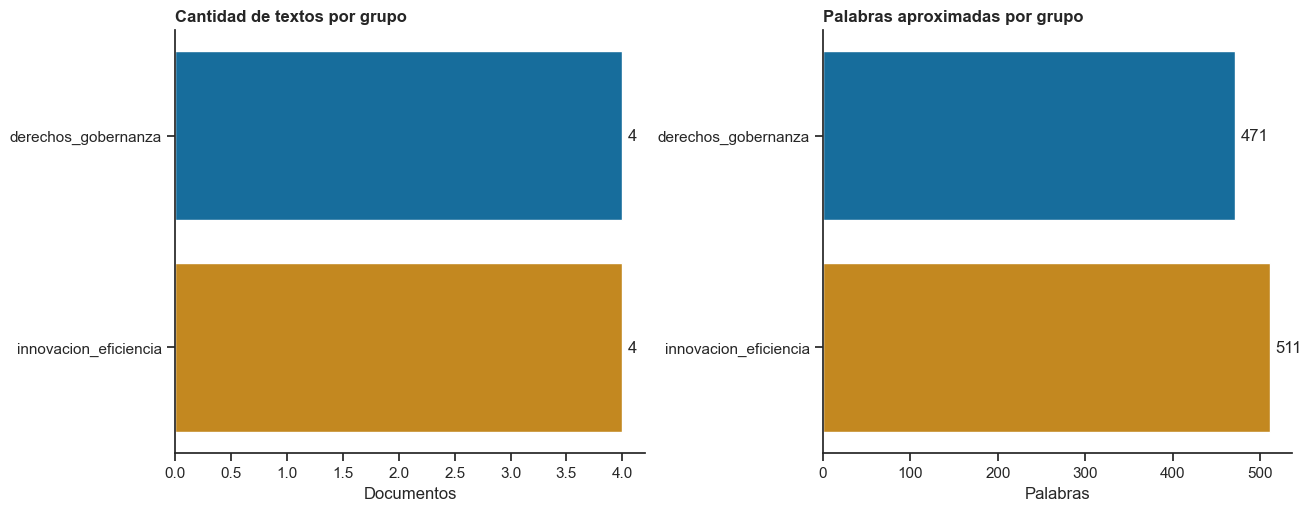

In [43]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [44]:
# Cargamos el modelo de spaCy
import spacy

try:
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception:
    print(
        "Aviso: no se encontró el modelo es_core_news_sm. "
        "Se usará `spacy.blank('es')` (sin lematización/NER avanzada)."
    )
    nlp = spacy.blank("es")

Aviso: no se encontró el modelo es_core_news_sm. Se usará `spacy.blank('es')` (sin lematización/NER avanzada).


In [45]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


,titulo,grupo_comparacion,texto_contenido
0,Aulas aumentadas: IA como tutor cotidiano en secundaria,innovacion_eficiencia,escuelas técnicas conurbano piloto tutorías ia redujo repitencia matemática datos ministerio provincial programa reemplaza docentes bloq...
1,Municipios incorporan IA para orientar búsquedas laborales,innovacion_eficiencia,oficinas empleo municipal implementaron asistentes conversacionales orientar jóvenes redacción cv simulación entrevistas mapeo cursos co...
2,Hospitales prueban triage asistido por modelos clínicos,innovacion_eficiencia,hospitales metropolitanos iniciaron pruebas controladas triage asistido modelos clínicos priorizan casos respiratorios cardiovasculares ...
3,Productividad pyme: asistentes de IA y reorganización del trabajo,innovacion_eficiencia,relevamiento cámaras industriales mostró pymes adoptó asistentes ia tareas administrativas compras atención posventa rediseño procesos p...
4,La escuela dataficada: cuando medir todo no mejora aprender,derechos_gobernanza,incorporación analítica educativa plataformas escolares promete detectar rezagos tempranos múltiples investigaciones muestran rendimient...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [46]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,derechos_gobernanza,decisiones,4
1,derechos_gobernanza,modelos,3
2,derechos_gobernanza,datos,3
3,derechos_gobernanza,educativa,2
4,derechos_gobernanza,muestran,2
5,derechos_gobernanza,tiempo,2
6,derechos_gobernanza,métricas,2
7,derechos_gobernanza,indicadores,2
8,derechos_gobernanza,lógica,2
9,derechos_gobernanza,sistema,2


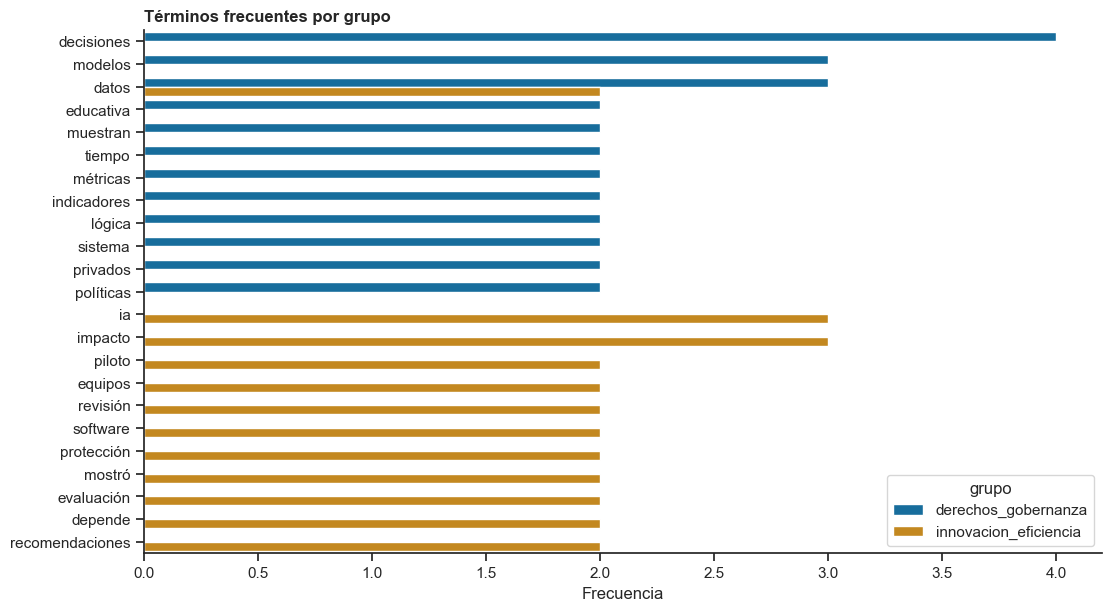

In [47]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [48]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


No se detectaron entidades suficientes para armar una tabla de trabajo.


In [49]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,derechos_gobernanza,vuelve retórica,1
1,derechos_gobernanza,abrió disputa,1
2,derechos_gobernanza,vuelve excepcional,1
3,derechos_gobernanza,vacío requiere,1
4,derechos_gobernanza,transparencia contractual,1
5,derechos_gobernanza,transición certificaciones,1
6,derechos_gobernanza,trabajadores call,1
7,derechos_gobernanza,tiempo monitoreo,1
8,derechos_gobernanza,tiempo estudio,1
9,derechos_gobernanza,territorial empresas,1


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [50]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,derechos_gobernanza,incorporación analítica educativa plataformas escolares promete detectar rezagos tempranos múltiples investigaciones muestran rendimient...
1,innovacion_eficiencia,escuelas técnicas conurbano piloto tutorías ia redujo repitencia matemática datos ministerio provincial programa reemplaza docentes bloq...


In [51]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,derechos_gobernanza,debería,2.0
1,derechos_gobernanza,contractual,2.0
2,derechos_gobernanza,educativa,2.0
3,derechos_gobernanza,muestran,2.0
4,derechos_gobernanza,lógica,2.0
5,derechos_gobernanza,ex,2.0
6,derechos_gobernanza,políticas,2.0
7,derechos_gobernanza,privados,2.0
8,derechos_gobernanza,sistemas,2.0
9,derechos_gobernanza,salud,2.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,derechos_gobernanza,debería,0.0130
1,derechos_gobernanza,contractual,0.0130
2,derechos_gobernanza,educativa,0.0130
3,derechos_gobernanza,muestran,0.0130
4,derechos_gobernanza,lógica,0.0130
5,derechos_gobernanza,ex,0.0130
6,derechos_gobernanza,políticas,0.0130
7,derechos_gobernanza,privados,0.0130
8,derechos_gobernanza,sistemas,0.0130
9,derechos_gobernanza,salud,0.0130


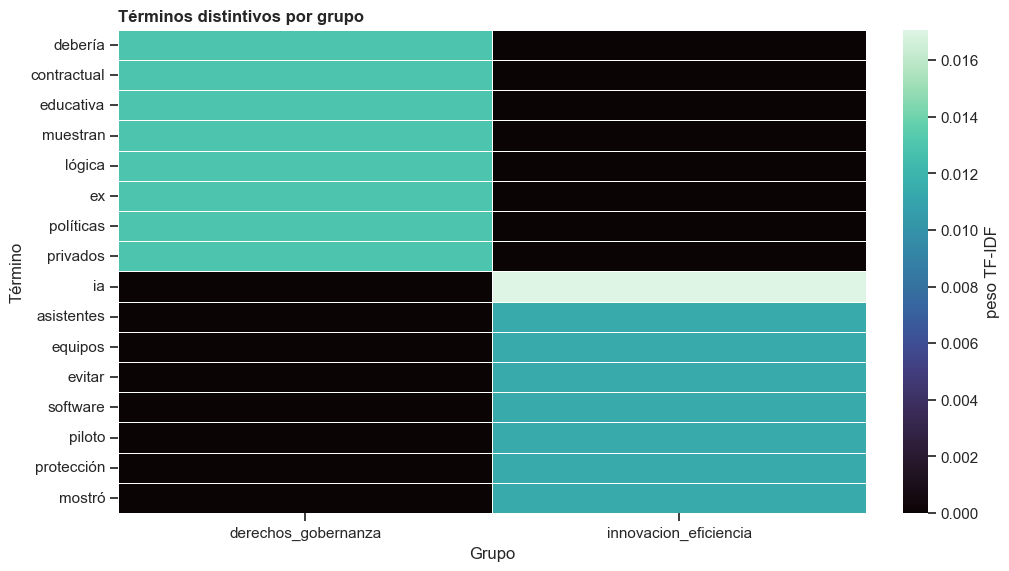

In [52]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [53]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,derechos_gobernanza,debería,0.0130
1,derechos_gobernanza,contractual,0.0130
2,innovacion_eficiencia,ia,0.0171
3,innovacion_eficiencia,asistentes,0.0114


In [54]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,derechos_gobernanza,debería,Automatización y empleo: el costo oculto de la transición,...on efectos en estrés y rotación. La mejora de indicadores de productividad convive con deterioro del clima laboral.\n\nUna agenda res...
1,derechos_gobernanza,debería,Salud digital y sesgos: por qué la auditoría no es opcional,...gregadas por grupo social. También plantean mecanismos de apelación clínica para decisiones automatizadas de alto impacto.\n\nLa disc...
2,derechos_gobernanza,contractual,Automatización y empleo: el costo oculto de la transición,"...onvive con deterioro del clima laboral.\n\nUna agenda responsable debería medir no solo puestos creados, sino calidad del empleo, est..."
3,derechos_gobernanza,contractual,¿Quién gobierna los algoritmos públicos?,...a ciudadanía no puede cuestionar decisiones que afectan derechos.\n\nExperiencias internacionales muestran que las cláusulas de trans...
4,innovacion_eficiencia,ia,Aulas aumentadas: IA como tutor cotidiano en secundaria,"En tres escuelas técnicas del conurbano, un piloto de tutorías con IA redujo en 18% la repitencia en matemática según datos del Minister..."
5,innovacion_eficiencia,ia,Productividad pyme: asistentes de IA y reorganización del trabajo,"Un relevamiento de cámaras industriales mostró que 42% de pymes adoptó asistentes de IA para tareas administrativas, compras y atención ..."
6,innovacion_eficiencia,asistentes,Municipios incorporan IA para orientar búsquedas laborales,"Cinco oficinas de empleo municipal implementaron asistentes conversacionales para orientar a jóvenes en la redacción de CV, simulación d..."
7,innovacion_eficiencia,asistentes,Productividad pyme: asistentes de IA y reorganización del trabajo,"Un relevamiento de cámaras industriales mostró que 42% de pymes adoptó asistentes de IA para tareas administrativas, compras y atención ..."


## 10. Escritura interpretativa

### 1) Recorte y comparación
El contraste enfrenta dos modos de enunciación sobre IA: **innovación/eficiencia** frente a **derechos/gobernanza**. La comparación es válida porque ambos grupos discuten los mismos campos sociales (escuela, empleo, salud y gestión pública), pero con marcos normativos distintos.

### 2) Lectura distante
En `innovacion_eficiencia` predominan términos asociados a adopción, solución y mejora de desempeño (por ejemplo, productividad, asistencia, implementación, optimización). En `derechos_gobernanza` ganan peso términos ligados a regulación, riesgos y accountability (sesgo, auditoría, derechos, control, gobernanza).

La diferencia entre BoW y TF-IDF fue clave:

- **BoW** mostró el vocabulario de mayor volumen en cada serie.
- **TF-IDF** permitió detectar términos menos frecuentes globalmente pero más específicos de cada encuadre discursivo.

Ese cruce evitó confundir frecuencia con relevancia interpretativa.

### 3) Lectura cercana
Al volver a los fragmentos, los términos distintivos adquieren función argumentativa:

- En `innovacion_eficiencia`, la IA aparece como infraestructura de apoyo para acelerar decisiones y mejorar resultados institucionales.
- En `derechos_gobernanza`, la IA se presenta como objeto de disputa política: quién define criterios, cómo se audita y qué garantías protegen a los afectados.

La diferencia no es solo léxica: cambia el foco enunciativo. Un grupo formula **potencial de uso**; el otro, **condiciones de legitimidad** de ese uso.

### 4) Visualización y método
Las visualizaciones más útiles para este corpus fueron:

1. barras de documentos/palabras por grupo (control de comparabilidad);
2. heatmap TF-IDF (separación de vocabulario distintivo).

Límites del enfoque:

- Las representaciones sparse no capturan matices pragmáticos ni posicionamientos implícitos.
- Un término puede concentrarse por repetición temática de una nota y no por centralidad discursiva estable.
- El modelo `es_core_news_sm` puede perder precisión en entidades compuestas o referencias institucionales.

Por eso, las conclusiones se sostienen como lectura situada del corpus seleccionado, triangulando frecuencia, especificidad y fragmentos textuales.


In [55]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
